## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting? 
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Payton Gergen

**Date:** 9/30/26

### Question 1

1. Regression predicts a numeric outcome, whereas classification predicts what category an object would fall in.

2. A confusion table counts predictions from classification by actual and predicted class. It shows for which groups the classification algorithm has a high accuracy and where it has low accuracy.

3. SSE is the sum of the squared residuals. Lower SSE indicates smaller errors.

4. Overfitting occurs when the value of k is too small, and it makes too many classifications based on noise. Underfitting occurs when the value of k is too large, and it provides too few predictions, grouping predictions that should not be grouped together.

5. Splitting into training and testing sets ensures that the model is validated for accuracy on a different set of data than it was trained on, measuring whether then model is generalizable beyond the training data. A model can fit its training data well by fitting noise in the sample, so selecting a value of k based on the separate validation dataset improves model performance.

6. Reporting a class label as a prediction can be useful when you need to make a single decision. However, predictions can abruptly change. Reporting the probability distribution over class labels can demonstrate where uncertainty takes place and show where there are multiple similarly likely labels.

### Question 2: Predict mine type

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

#### Part 1: Load and examine data

In [52]:
mines = pd.read_csv("data/land_mines.csv")
mines

,voltage,height,soil,mine_type
0,0.338157,0.000000,0.0,1
1,0.320241,0.181818,0.0,1
2,0.287009,0.272727,0.0,1
3,0.256284,0.454545,0.0,1
4,0.262840,0.545455,0.0,1
...,...,...,...,...
333,0.323262,0.909091,0.4,5
334,0.444108,0.181818,1.0,5
335,0.353474,0.454545,1.0,5
336,0.362537,0.727273,1.0,5


(array([ 45., 123.,  62.,  42.,  19.,  10.,   7.,   4.,   5.,  21.]),
 array([0.19773388, 0.27796036, 0.35818685, 0.43841333, 0.51863982,
        0.5988663 , 0.67909279, 0.75931927, 0.83954576, 0.91977224,
        0.99999873]),
 <BarContainer object of 10 artists>)

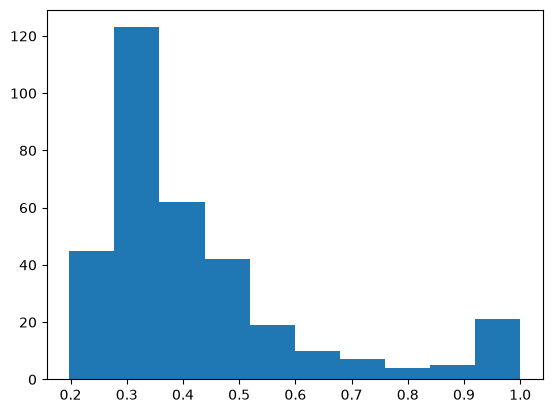

In [53]:
plt.hist(mines["voltage"])

Voltage falls withhin 0 and 1, with most of the data being below 0.6.

(array([49., 30., 28., 29., 29., 30., 30., 29., 29., 55.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

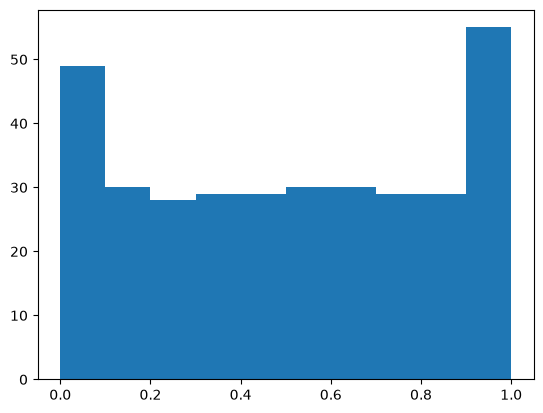

In [54]:
plt.hist(mines["height"])

Height is approximately uniformly distributed from 0 to 1.

(array([59.,  0., 51.,  0., 56., 57.,  0.,  0., 58., 57.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

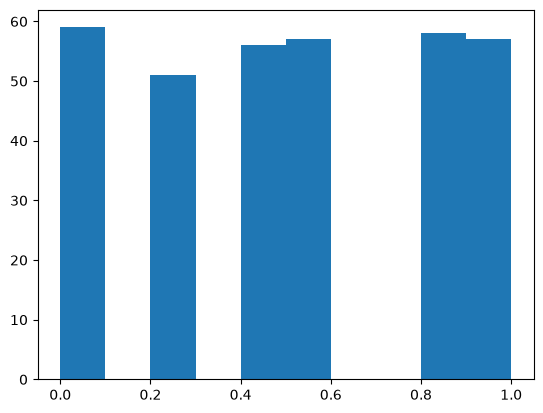

In [55]:
plt.hist(mines["soil"])

In [56]:
mines["soil"].unique()

array([0. , 0.6, 0.2, 0.8, 0.4, 1. ])

Soil takes on a value of 0, 0.2, 0.4, 0.6, 0.8, or 1.

(array([71.,  0., 70.,  0.,  0., 66.,  0., 66.,  0., 65.]),
 array([1. , 1.4, 1.8, 2.2, 2.6, 3. , 3.4, 3.8, 4.2, 4.6, 5. ]),
 <BarContainer object of 10 artists>)

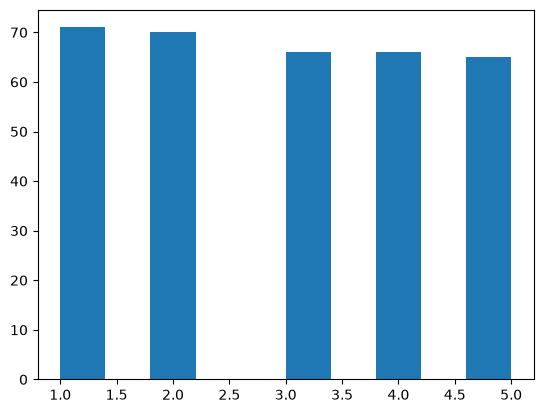

In [57]:
plt.hist(mines["mine_type"])

In [58]:
mines["mine_type"].unique()

array([1, 2, 3, 4, 5])

All mine types are 1, 2, 3, 4, or 5, with each value having about the same number of mines.

#### Part 2: Split training and validation sets

In [59]:
eval_X_raw = mines[["voltage", "height", "soil"]] # Training variables
eval_y = mines["mine_type"] # Target variable

# Split data
(
    eval_X_train_raw,
    eval_X_valid_raw,
    eval_y_train,
    eval_y_valid,
) = train_test_split(
    eval_X_raw, eval_y, test_size=0.5, random_state = 10
)

# Scale data
eval_scaler = MinMaxScaler()
eval_X_train_scaled = eval_scaler.fit_transform(eval_X_train_raw)
eval_X_valid_scaled = eval_scaler.fit_transform(eval_X_valid_raw)

#### Part 3: Build kNN classifier

In [60]:
# We expect the optimal k value to be around the square root of N
np.sqrt(len(mines))

np.float64(18.384776310850235)

In [61]:
eval_ks = np.arange(1,30) # Test values of k between 10 and 30

eval_valid_sse = []
eval_train_sse = []

for k in eval_ks: # Test out each value of k in eval_ks to deteremine which one minimizes validation SSE
    eval_candidate = KNeighborsRegressor(n_neighbors = int(k))
    eval_candidate.fit(eval_X_train_scaled, eval_y_train)
    eval_valid_prediction = eval_candidate.predict(eval_X_valid_scaled)
    eval_train_prediction = eval_candidate.predict(eval_X_train_scaled)
    eval_valid_sse.append(np.sum((eval_y_valid.to_numpy() - eval_valid_prediction) ** 2)) # Calculate and append validation SSE
    eval_train_sse.append(np.sum((eval_y_train.to_numpy() - eval_train_prediction) ** 2)) # Calculuate and append training SSE

optimal_k = int(eval_ks[np.argmin(eval_valid_sse)])
optimal_k

15

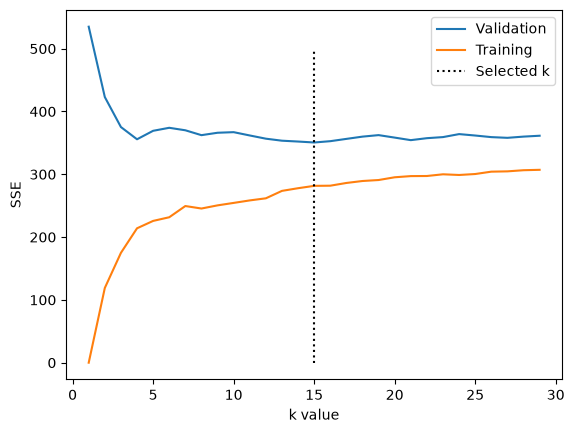

In [62]:
# Plot training and validation SSEs

plt.plot(eval_ks, eval_valid_sse, label = "Validation")
plt.plot(eval_ks, eval_train_sse, label = "Training")

plt.vlines(15, ymin = 0, ymax = 500, color = "black", label = "Selected k", linestyles=":")

plt.xlabel("k value")
plt.ylabel("SSE")
plt.legend()

The value of k was selected by testing integers from 1 to 30. A model was fit for each value of k, and the SSE was calculated for the training and validation sets. The optimal k value was selected by identifying the value that minimized the validation SSE.

In [63]:
classification_X_raw = mines[["voltage", "height", "soil"]]
classification_y = mines["mine_type"]

classification_scaler = MinMaxScaler()
classification_X_scaled = pd.DataFrame(
    classification_scaler.fit_transform(classification_X_raw),
    columns=classification_X_raw.columns,
    index=classification_X_raw.index,
)
classification_model = KNeighborsClassifier(n_neighbors=15).fit(
    classification_X_scaled, classification_y
)

#### Part 4: Confusion Table

In [64]:
y_pred = classification_model.predict(classification_X_scaled)
confusion = confusion_matrix(classification_y, y_pred)
confusion

array([[66,  0,  4,  0,  1],
       [ 0, 65,  2,  3,  0],
       [ 9,  2, 31,  9, 15],
       [26,  3, 14, 16,  7],
       [16,  0, 22,  8, 19]])

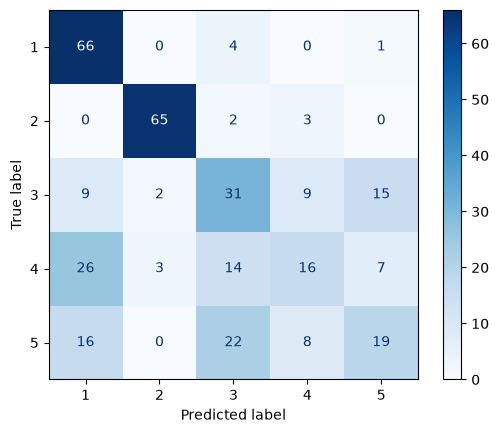

In [65]:
disp = ConfusionMatrixDisplay(confusion_matrix=confusion, display_labels=["1", "2", "3", "4", "5"])
disp.plot(cmap="Blues")
plt.grid(False)
plt.show()

In [66]:
(66+65+31+16+19) / confusion.sum()

np.float64(0.5828402366863905)

The confusion matrix indicates that the model correctly predicted 58% of the mine types. It did a good job of predicting type 2, but it performed poorly for the other types. Because this would be used for potentially high-risk tasks relating to land mines, I would caution against reliance on this model.

#### Part 5: Advice on model use

If you want to identify type 2, this is a good model to use. Otherwise, I  would use the model knowing that there will be a high percent of errors.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** bd1745d
- **AI tool and model used:** Claude Sonnet 5.5

### *Prompts used

1. analyze my work and give me a concise numbered list of recommended changes.

### *AI-proposed changes


1. Fit the scaler on training data only (cell 23). fit_transform is called on the validation set, so the validation features are scaled with their own min and max. Use transform instead, so both sets share the training scaling.
2. Use KNeighborsClassifier to choose k, not KNeighborsRegressor (cell 26). The regressor averages the labels 1–5 as if they were numeric, so SSE treats a type 1 vs. type 5 miss as 16× worse than 1 vs. 2. Select k by validation accuracy or error rate instead.
3. Evaluate the confusion table on the validation set (cells 29–33). The final model is refit on all the data, then the confusion matrix is computed on that same data, so the 58% is training accuracy. The task asks for the optimal model on the test set. Fit on the training half and predict on the validation half.
4. Pick k with code, not by hand (cells 27, 29). 15 is hardcoded in the plot and the final model. Use optimal_k in both places, and set ymax from the data.
5. Fix the k-search range and comments (cells 25–26). Your comment says "between 10 and 30" but the range is 1–29, and the markdown says 1 to 30. Also, the √N heuristic is computed on the full dataset (N = 338) but you train on 169 points. Either adjust it or note that the search range covers it.
6. Compute the accuracy from the matrix (cell 33). Replace the hand-typed diagonal with np.trace(confusion) / confusion.sum(). Also report per-class precision and recall, since you already import classification_report. Part 4 asks where accuracy is higher or lower, and you currently name only type 2.
7. Strengthen the Part 4 and Part 5 discussion. Your matrix shows type 1 is also predicted well (66 of 71), and type 4 is mostly misclassified as type 1 (26 of 66). Part 5 should go beyond "high error rate" and cover:
    - Which predictions to trust (types 1 and 2) and which to treat as uncertain (types 3, 4, 5).
    - Using predict_proba to flag low-confidence cases for follow-up.
    - Using the confusion pattern to decide how dangerous each kind of error is, rather than treating all errors alike.
8. Add EDA that supports your claims (Part 1). Show mines.describe() and value_counts() for mine_type. A single value_counts() backs up "about the same number of each" better than the histogram. Label the axes and titles, and add an interpretation for the soil histogram (cell 16), which has none. Also note that height and soil are discrete grids, not continuous. Clarify that voltage ranges from 0 to 1 and not just "below 0.6."
9. Stratify the split (cell 23). Add stratify=eval_y so each class is proportionally represented in both halves, which matters with only 338 rows and 5 classes.
10. Tighten the Question 1 answers.
    Q4: underfitting is a model too simple to capture the real pattern, not "too few predictions." Also add that overfit models show low training error and high validation error.
    Q6: mention that probabilities let a user set their own decision thresholds, and that they cost more to interpret and require calibration.
11. Minor cleanup. Fix the typos ("withhin," "deteremine," "Calculuate," "whether then model"), and remove the unused imports (classification_report and others).

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Reject | The slides from class specify to split before scaling |
| 2 | Reject | I followed the steps from the slides, which uses KNeighborsRegressor |
| 3 | Accept | Build model on training dataset and predict on validation set to better measure model performance and generalizability |
| 4 | Reject | k=15 is the correct k, so this is not necessary |
| 5 | Accept | Discrepany between code and comment |
| 6 | Modify | Replaced typed diagonal with np.trace(confusion) for completeness |
| 7 | Reject | Not necessary, I already answered the questions |
| 8 | Reject | Not necessary |
| 9 | Rejecct | Not necessary to stratify |
| 10 | Reject | Not necessary |
| 11 | Accept | Fixed typos |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

### Question 1

1. Regression predicts a numeric outcome, whereas classification predicts what category an object would fall in.

2. A confusion table counts predictions from classification by actual and predicted class. It shows for which groups the classification algorithm has a high accuracy and where it has low accuracy.

3. SSE is the sum of the squared residuals. Lower SSE indicates smaller errors.

4. Overfitting occurs when the value of k is too small, and it makes too many classifications based on noise. Underfitting occurs when the value of k is too large, and it provides too few predictions, grouping predictions that should not be grouped together.

5. Splitting into training and testing sets ensures that the model is validated for accuracy on a different set of data than it was trained on, measuring whether the model is generalizable beyond the training data. A model can fit its training data well by fitting noise in the sample, so selecting a value of k based on the separate validation dataset improves model performance.

6. Reporting a class label as a prediction can be useful when you need to make a single decision. However, predictions can abruptly change. Reporting the probability distribution over class labels can demonstrate where uncertainty takes place and show where there are multiple similarly likely labels.

### Question 2: Predict mine type

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

#### Part 1: Load and examine data

In [ ]:
mines = pd.read_csv("data/land_mines.csv")
mines

,voltage,height,soil,mine_type
0,0.338157,0.000000,0.0,1
1,0.320241,0.181818,0.0,1
2,0.287009,0.272727,0.0,1
3,0.256284,0.454545,0.0,1
4,0.262840,0.545455,0.0,1
...,...,...,...,...
333,0.323262,0.909091,0.4,5
334,0.444108,0.181818,1.0,5
335,0.353474,0.454545,1.0,5
336,0.362537,0.727273,1.0,5


(array([ 45., 123.,  62.,  42.,  19.,  10.,   7.,   4.,   5.,  21.]),
 array([0.19773388, 0.27796036, 0.35818685, 0.43841333, 0.51863982,
        0.5988663 , 0.67909279, 0.75931927, 0.83954576, 0.91977224,
        0.99999873]),
 <BarContainer object of 10 artists>)

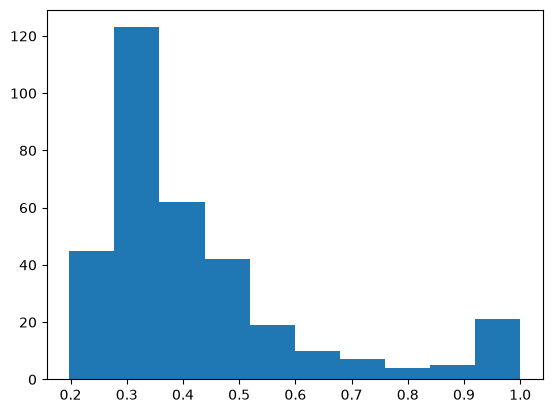

In [ ]:
plt.hist(mines["voltage"])

Voltage falls within 0 and 1, with most of the data being below 0.6.

(array([49., 30., 28., 29., 29., 30., 30., 29., 29., 55.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

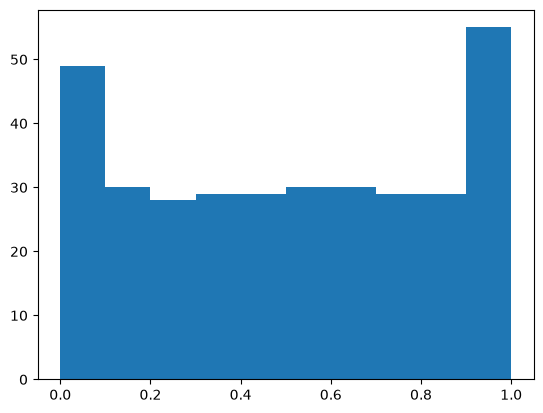

In [ ]:
plt.hist(mines["height"])

Height is approximately uniformly distributed from 0 to 1.

(array([59.,  0., 51.,  0., 56., 57.,  0.,  0., 58., 57.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

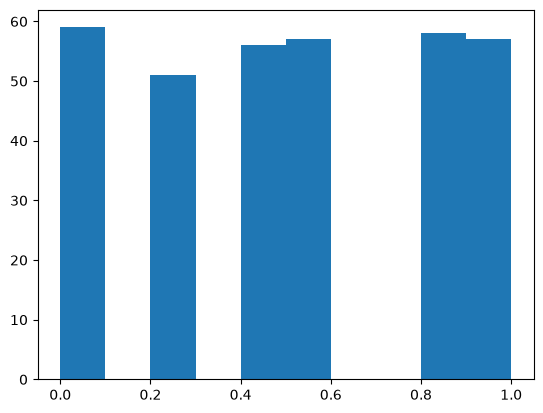

In [ ]:
plt.hist(mines["soil"])

In [ ]:
mines["soil"].unique()

array([0. , 0.6, 0.2, 0.8, 0.4, 1. ])

Soil takes on a value of 0, 0.2, 0.4, 0.6, 0.8, or 1.

(array([71.,  0., 70.,  0.,  0., 66.,  0., 66.,  0., 65.]),
 array([1. , 1.4, 1.8, 2.2, 2.6, 3. , 3.4, 3.8, 4.2, 4.6, 5. ]),
 <BarContainer object of 10 artists>)

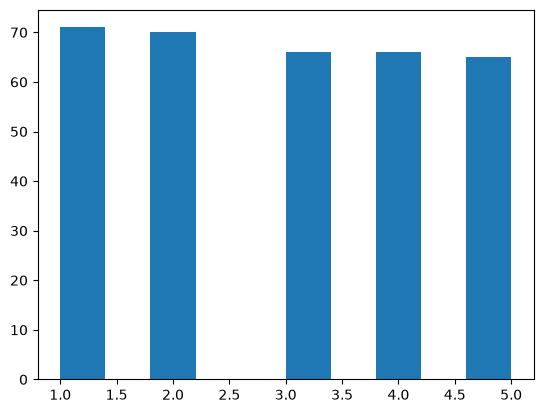

In [ ]:
plt.hist(mines["mine_type"])

In [ ]:
mines["mine_type"].unique()

array([1, 2, 3, 4, 5])

All mine types are 1, 2, 3, 4, or 5, with each value having about the same number of mines.

#### Part 2: Split training and validation sets

In [ ]:
eval_X_raw = mines[["voltage", "height", "soil"]] # Training variables
eval_y = mines["mine_type"] # Target variable

# Split data
(
    eval_X_train_raw,
    eval_X_valid_raw,
    eval_y_train,
    eval_y_valid,
) = train_test_split(
    eval_X_raw, eval_y, test_size=0.5, random_state = 10
)

# Scale data
eval_scaler = MinMaxScaler()
eval_X_train_scaled = eval_scaler.fit_transform(eval_X_train_raw)
eval_X_valid_scaled = eval_scaler.fit_transform(eval_X_valid_raw)

#### Part 3: Build kNN classifier

In [ ]:
# We expect the optimal k value to be around the square root of N
np.sqrt(len(mines))

np.float64(18.384776310850235)

In [ ]:
eval_ks = np.arange(1,30) # Test values of k between 10 and 30

eval_valid_sse = []
eval_train_sse = []

for k in eval_ks: # Test out each value of k in eval_ks to determine which one minimizes validation SSE
    eval_candidate = KNeighborsRegressor(n_neighbors = int(k))
    eval_candidate.fit(eval_X_train_scaled, eval_y_train)
    eval_valid_prediction = eval_candidate.predict(eval_X_valid_scaled)
    eval_train_prediction = eval_candidate.predict(eval_X_train_scaled)
    eval_valid_sse.append(np.sum((eval_y_valid.to_numpy() - eval_valid_prediction) ** 2)) # Calculate and append validation SSE
    eval_train_sse.append(np.sum((eval_y_train.to_numpy() - eval_train_prediction) ** 2)) # Calculate and append training SSE

optimal_k = int(eval_ks[np.argmin(eval_valid_sse)])
optimal_k

15

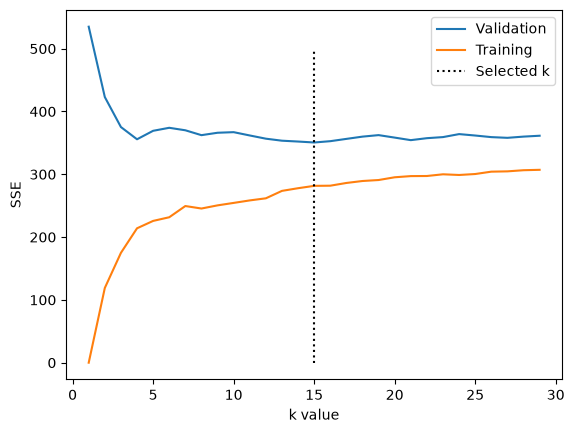

In [ ]:
# Plot training and validation SSEs

plt.plot(eval_ks, eval_valid_sse, label = "Validation")
plt.plot(eval_ks, eval_train_sse, label = "Training")

plt.vlines(15, ymin = 0, ymax = 500, color = "black", label = "Selected k", linestyles=":")

plt.xlabel("k value")
plt.ylabel("SSE")
plt.legend()

The value of k was selected by testing integers from 1 to 30. A model was fit for each value of k, and the SSE was calculated for the training and validation sets. The optimal k value was selected by identifying the value that minimized the validation SSE.

In [70]:
classification_model = KNeighborsClassifier(n_neighbors=15).fit(
    eval_X_train_scaled, eval_y_train
)

#### Part 4: Confusion Table

In [71]:
y_pred = classification_model.predict(eval_X_valid_scaled)
confusion = confusion_matrix(eval_y_valid, y_pred)
confusion

array([[24,  0,  8,  0,  0],
       [ 0, 29,  6,  2,  2],
       [10,  0, 12,  2,  1],
       [19,  0, 11,  3,  0],
       [17,  0, 18,  3,  2]])

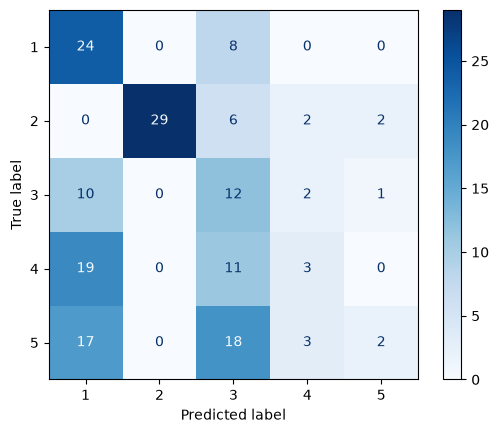

In [72]:
disp = ConfusionMatrixDisplay(confusion_matrix=confusion, display_labels=["1", "2", "3", "4", "5"])
disp.plot(cmap="Blues")
plt.grid(False)
plt.show()

In [73]:
np.trace(confusion) / confusion.sum()

np.float64(0.41420118343195267)

The confusion matrix indicates that the model correctly predicted 41% of the mine types. It did a good job of predicting type 2, but it performed poorly for the other types. Because this would be used for potentially high-risk tasks relating to land mines, I would caution against reliance on this model.

#### Part 5: Advice on model use

If you want to identify type 2, this is a good model to use. Otherwise, I  would use the model knowing that there will be a high percent of errors.

### *Reflection on AI assistance
In your own words without generative AI.

The main improvement made with the suggestions from AI was to build the model based on the training dataset and to predict based on the validation dataset. I had used the separate datasets properly to identify the optimal value of k to use, but I should also use the two datasets separately for training and validating the model to ensure that the accuracy reported accurately demonstrates the generalizability of the model. The percent of accurate predictions did decrease when I split the model training and validation like this, but the classes that were effectively or inaccurately predicted remained the same. Although some of the other minor grammatical changes suggested by AI were helpful, the majority of its other points were irrelevant to the questions in the assignment or would not make a difference in the code outputs. Thus, only one of the eleven suggestions led to substantiative changes to my work.